# 🚀 EDA - Tối ưu hóa Hệ thống Gợi ý Sản phẩm cho Tiki

**Pipeline theo yêu cầu:**
1. Phân tích hành vi người dùng  
2. Top sản phẩm được xem/mua nhiều nhất (dùng số review làm proxy)  
3. Visualize bằng matplotlib + seaborn

**Dataset:**  
- `tiki_all_products.csv`  
- `tiki_all_reviews.csv`

**Mục tiêu EDA:** Hiểu rõ dữ liệu trước khi xây SVD (Collaborative Filtering) và Content-Based Filtering.

#BƯỚC 1. IMPORT THƯ VIỆN

In [ ]:
import pandas as pd
import numpy as np

#BƯỚC 2. ĐỌC FILE DỮ LIỆU

In [ ]:
reviews = pd.read_csv('/content/Tiki_reviews.csv')
products = pd.read_csv('/content/Tiki_products.csv')

/tmp/ipykernel_13633/1750264811.py:1: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  reviews = pd.read_csv('/content/Tiki_reviews.csv')


#BƯỚC 3. XEM TỔNG QUAN DỮ LIỆU BAN ĐẦU

3.1. Xem 5 dòng đầu

In [ ]:
print("=== REVIEWS ===")
display(reviews.head())

print("=== PRODUCTS ===")
display(products.head())

=== REVIEWS ===


,product_id,product_name,category_name,review_id,title,content,rating,helpful_vote,status,created_at,customer_id,customer_name,purchased_at,is_purchased
0,278871248,Máy Tính Xách Tay Laptop Samsung Galaxy Chrome...,laptop,20056790,Không hài lòng,"Chán, chậm, màn không nét",2,0,approved,1.735357e+09,9063447.0,Nguyenbtk,1.734768e+09,True
1,279257463,Điện Thoại Samsung Galaxy A37 5G (8GB/128GB) -...,dien_thoai,20223765,Cực kì hài lòng,NaN,5,0,approved,1.775214e+09,30646092.0,Hoai nhớ,1.775205e+09,True
2,279077087,Điện thoại Oppo A5i ( 6GB/128GB) - Hàng chính ...,dien_thoai,20209851,Cực kì hài lòng,NaN,5,0,approved,1.769872e+09,30513655.0,Vũ giáp,1.769670e+09,True
3,279076941,Điện thoại Oppo A5x (4GB/64GB) - Hàng chính hãng,dien_thoai,20223217,Cực kì hài lòng,NaN,5,0,approved,1.774962e+09,29818606.0,Lê Thị Hà,1.774829e+09,True
4,279074852,Điện Thoại Xiaomi Redmi 15C 6GB/128GB - Hàng C...,dien_thoai,20221243,Cực kì hài lòng,"máy bộ nhớ lớn, chụp ảnh đẹp pin trâu",5,0,approved,1.774139e+09,11651137.0,Hlo Ksor,1.773899e+09,True


=== PRODUCTS ===


,id,name,price,original_price,discount_rate,rating_average,review_count,thumbnail_url,url_key,category_id,category_name
0,279218630,Laptop Asus Vivobook Go E1404FA - EB482W (R5 7...,14500000,14990000,3,0.0,0,https://salt.tikicdn.com/cache/280x280/ts/prod...,laptop-asus-vivobook-14-x1404va-eb155w-core-5-...,8095,laptop
1,279217989,"Laptop Dell 15 DC15250 - DC5I7952W1 (i7 1355U,...",22990000,25990000,12,0.0,0,https://salt.tikicdn.com/cache/280x280/ts/prod...,laptop-dell-15-dc15250-dc5i7952w1-i7-1355u-16g...,8095,laptop
2,279217963,"Laptop Dell 15 DC15250 - DC5I5897W1 (i5 1334U,...",19990000,21990000,9,0.0,0,https://salt.tikicdn.com/cache/280x280/ts/prod...,laptop-dell-15-dc15250-dc5i5897w1-i5-1334u-16g...,8095,laptop
3,279217929,Laptop Dell 14 DC14250 - DC4C5386W (Core 5 120...,24990000,24990000,0,0.0,0,https://salt.tikicdn.com/cache/280x280/ts/prod...,laptop-dell-14-dc14250-dc4c5386w-core-5-120u-1...,8095,laptop
4,279217378,Laptop HP 14-ep1178TU core 5- 120U/RAM 16GB/1T...,22250000,22250000,0,0.0,0,https://salt.tikicdn.com/cache/280x280/ts/prod...,laptop-hp-14-ep1178tu-core-5-120u-ram-16gb-1tb...,8095,laptop


3.2. Kiểm tra kích thước dữ liệu

In [ ]:
print("Kích thước reviews:", reviews.shape)
print("Kích thước products:", products.shape)

Kích thước reviews: (71279, 14)
Kích thước products: (1165, 11)


3.3. Kiểm tra tên cột

In [ ]:
print("Cột của reviews:")
print(reviews.columns.tolist())

print("\nCột của products:")
print(products.columns.tolist())

Cột của reviews:
['product_id', 'product_name', 'category_name', 'review_id', 'title', 'content', 'rating', 'helpful_vote', 'status', 'created_at', 'customer_id', 'customer_name', 'purchased_at', 'is_purchased']

Cột của products:
['id', 'name', 'price', 'original_price', 'discount_rate', 'rating_average', 'review_count', 'thumbnail_url', 'url_key', 'category_id', 'category_name']


3.4. Kiểm tra kiểu dữ liệu

In [ ]:
print("Thông tin reviews:")
reviews.info()

print("\nThông tin products:")
products.info()

Thông tin reviews:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71279 entries, 0 to 71278
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_id     71279 non-null  int64  
 1   product_name   71279 non-null  object 
 2   category_name  71279 non-null  object 
 3   review_id      71279 non-null  int64  
 4   title          71275 non-null  object 
 5   content        23969 non-null  object 
 6   rating         71279 non-null  int64  
 7   helpful_vote   71279 non-null  int64  
 8   status         71278 non-null  object 
 9   created_at     71278 non-null  float64
 10  customer_id    71188 non-null  float64
 11  customer_name  71135 non-null  object 
 12  purchased_at   71091 non-null  float64
 13  is_purchased   71278 non-null  object 
dtypes: float64(3), int64(4), object(7)
memory usage: 7.6+ MB

Thông tin products:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1165 entries, 0 to 1164
Data column

#BƯỚC 4. KIỂM TRA GIÁ TRỊ THIẾU

4.1. Đếm số lượng missing value theo từng cột

In [ ]:
print("=== Missing values trong reviews ===")
print(reviews.isnull().sum())

print("\n=== Missing values trong products ===")
print(products.isnull().sum())

=== Missing values trong reviews ===
product_id           0
product_name         0
category_name        0
review_id            0
title                4
content          47310
rating               0
helpful_vote         0
status               1
created_at           1
customer_id         91
customer_name      144
purchased_at       188
is_purchased         1
dtype: int64

=== Missing values trong products ===
id                0
name              0
price             0
original_price    0
discount_rate     0
rating_average    0
review_count      0
thumbnail_url     0
url_key           0
category_id       0
category_name     0
dtype: int64


4.2. Tính tỷ lệ missing (%)

In [ ]:
print("=== Tỷ lệ missing của reviews (%) ===")
print((reviews.isnull().sum() / len(reviews)) * 100)

print("\n=== Tỷ lệ missing của products (%) ===")
print((products.isnull().sum() / len(products)) * 100)

=== Tỷ lệ missing của reviews (%) ===
product_id        0.000000
product_name      0.000000
category_name     0.000000
review_id         0.000000
title             0.005612
content          66.372985
rating            0.000000
helpful_vote      0.000000
status            0.001403
created_at        0.001403
customer_id       0.127667
customer_name     0.202023
purchased_at      0.263752
is_purchased      0.001403
dtype: float64

=== Tỷ lệ missing của products (%) ===
id                0.0
name              0.0
price             0.0
original_price    0.0
discount_rate     0.0
rating_average    0.0
review_count      0.0
thumbnail_url     0.0
url_key           0.0
category_id       0.0
category_name     0.0
dtype: float64


#BƯỚC 5. KIỂM TRA DÒNG TRÙNG LẶP

In [ ]:
print("Số dòng trùng trong reviews:", reviews.duplicated().sum())
print("Số dòng trùng trong products:", products.duplicated().sum())

Số dòng trùng trong reviews: 3
Số dòng trùng trong products: 0


#BƯỚC 6. TẠO BẢN SAO DỮ LIỆU ĐỂ CLEANING

Không nên sửa trực tiếp file gốc, nên tạo bản sao:

In [ ]:
reviews_clean = reviews.copy()
products_clean = products.copy()

#BƯỚC 7. XÓA DÒNG TRÙNG LẶP

In [ ]:
reviews_clean = reviews_clean.drop_duplicates()
products_clean = products_clean.drop_duplicates()

print("Kích thước reviews sau khi xóa duplicate:", reviews_clean.shape)
print("Kích thước products sau khi xóa duplicate:", products_clean.shape)

Kích thước reviews sau khi xóa duplicate: (71276, 14)
Kích thước products sau khi xóa duplicate: (1165, 11)


#BƯỚC 8. XỬ LÝ GIÁ TRỊ THIẾU

8.1. Với bảng reviews

In [ ]:
reviews_clean = reviews_clean.dropna(subset=['product_id', 'customer_id', 'rating'])

8.2. Với cột text như title, content

In [ ]:
reviews_clean['title'] = reviews_clean['title'].fillna('')
reviews_clean['content'] = reviews_clean['content'].fillna('')

8.3. Với bảng products

In [ ]:
products_clean['name'] = products_clean['name'].fillna('Unknown Product')
products_clean['category_name'] = products_clean['category_name'].fillna('Unknown Category')

#BƯỚC 9. CHUYỂN ĐỔI KIỂU DỮ LIỆU

9.1. Chuyển rating về numeric

In [ ]:
reviews_clean['rating'] = pd.to_numeric(reviews_clean['rating'], errors='coerce')

In [ ]:
reviews_clean = reviews_clean.dropna(subset=['rating'])

9.2. Chuyển created_at về datetime

In [ ]:
reviews_clean['created_at'] = pd.to_datetime(reviews_clean['created_at'], errors='coerce')

9.3. Chuyển purchased_at về datetime nếu cần

In [ ]:
reviews_clean['purchased_at'] = pd.to_datetime(reviews_clean['purchased_at'], errors='coerce')

#BƯỚC 10. KIỂM TRA GIÁ TRỊ BẤT HỢP LÝ

10.1. Kiểm tra rating có nằm trong khoảng hợp lệ không

In [ ]:
print("Các giá trị rating duy nhất:")
print(sorted(reviews_clean['rating'].dropna().unique()))

Các giá trị rating duy nhất:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


Lọc các rating hợp lệ:

In [ ]:
reviews_clean = reviews_clean[(reviews_clean['rating'] >= 1) & (reviews_clean['rating'] <= 5)]

10.2. Kiểm tra giá sản phẩm âm hoặc bằng 0

In [ ]:
print("Số sản phẩm có giá <= 0:", (products_clean['price'] <= 0).sum())

Số sản phẩm có giá <= 0: 0


#BƯỚC 11. LỌC USER CÓ QUÁ ÍT TƯƠNG TÁC

11.1. Đếm số lượng interaction của mỗi user

In [ ]:
user_interaction_counts = reviews_clean['customer_id'].value_counts()
print(user_interaction_counts.head())

customer_id
29964376.0    40
5917418.0     40
17506038.0    25
1290988.0     23
9786862.0     19
Name: count, dtype: int64


11.2. Giữ lại user có từ 2 interactions trở lên

In [ ]:
valid_users = user_interaction_counts[user_interaction_counts >= 2].index
reviews_clean = reviews_clean[reviews_clean['customer_id'].isin(valid_users)]

11.3. Kiểm tra lại số user

In [ ]:
print("Số user sau khi lọc:", reviews_clean['customer_id'].nunique())

Số user sau khi lọc: 9229


#BƯỚC 12. ĐỒNG BỘ REVIEWS VỚI PRODUCTS

In [ ]:
reviews_clean = reviews_clean[reviews_clean['product_id'].isin(products_clean['id'])]

In [ ]:
products_clean = products_clean[products_clean['id'].isin(reviews_clean['product_id'])]

#BƯỚC 13. KIỂM TRA KẾT QUẢ SAU CLEANING

In [ ]:
print("=== KẾT QUẢ SAU CLEANING ===")
print("Số dòng reviews:", len(reviews_clean))
print("Số user:", reviews_clean['customer_id'].nunique())
print("Số product trong reviews:", reviews_clean['product_id'].nunique())
print("Số product trong products:", products_clean['id'].nunique())

=== KẾT QUẢ SAU CLEANING ===
Số dòng reviews: 22366
Số user: 9229
Số product trong reviews: 139
Số product trong products: 139


In [ ]:
print("\nMissing values trong reviews_clean:")
print(reviews_clean.isnull().sum())

print("\nMissing values trong products_clean:")
print(products_clean.isnull().sum())


Missing values trong reviews_clean:
product_id        0
product_name      0
category_name     0
review_id         0
title             0
content           0
rating            0
helpful_vote      0
status            0
created_at        0
customer_id       0
customer_name    26
purchased_at     11
is_purchased      0
dtype: int64

Missing values trong products_clean:
id                0
name              0
price             0
original_price    0
discount_rate     0
rating_average    0
review_count      0
thumbnail_url     0
url_key           0
category_id       0
category_name     0
dtype: int64


In [ ]:
print("\nDuplicate reviews còn lại:", reviews_clean.duplicated().sum())
print("Duplicate products còn lại:", products_clean.duplicated().sum())


Duplicate reviews còn lại: 0
Duplicate products còn lại: 0


In [ ]:
reviews_clean.to_csv('/content/Tiki_reviews_clean.csv', index=False)
products_clean.to_csv('/content/Tiki_products_clean.csv', index=False)

#**EDA**

#🔥 SETUP

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Style chuyên nghiệp
sns.set_theme(style="whitegrid", palette="Set2")

# Kích thước chuẩn đồ án
plt.rcParams['figure.figsize'] = (10,6)

# Use the cleaned dataframes already in memory
reviews = reviews_clean.copy() # Using the reviews_clean dataframe
products = products_clean.copy() # Using the products_clean dataframe

⭐ 1. PHÂN PHỐI RATING

/tmp/ipykernel_13633/2467179634.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews, x='rating', palette='viridis')


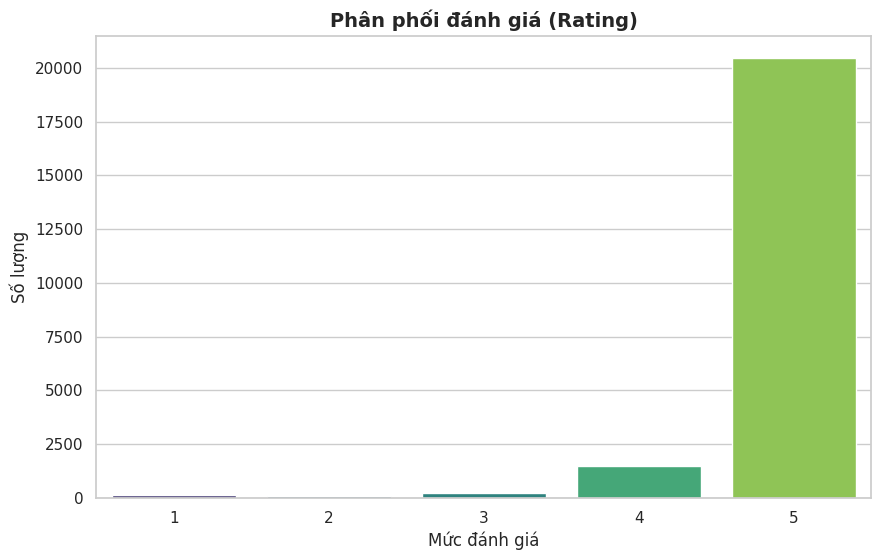

In [ ]:
sns.countplot(data=reviews, x='rating', palette='viridis')

plt.title("Phân phối đánh giá (Rating)", fontsize=14, fontweight='bold')
plt.xlabel("Mức đánh giá", fontsize=12)
plt.ylabel("Số lượng", fontsize=12)

plt.show()

📦 2. PHÂN PHỐI SỐ REVIEW THEO SẢN PHẨM

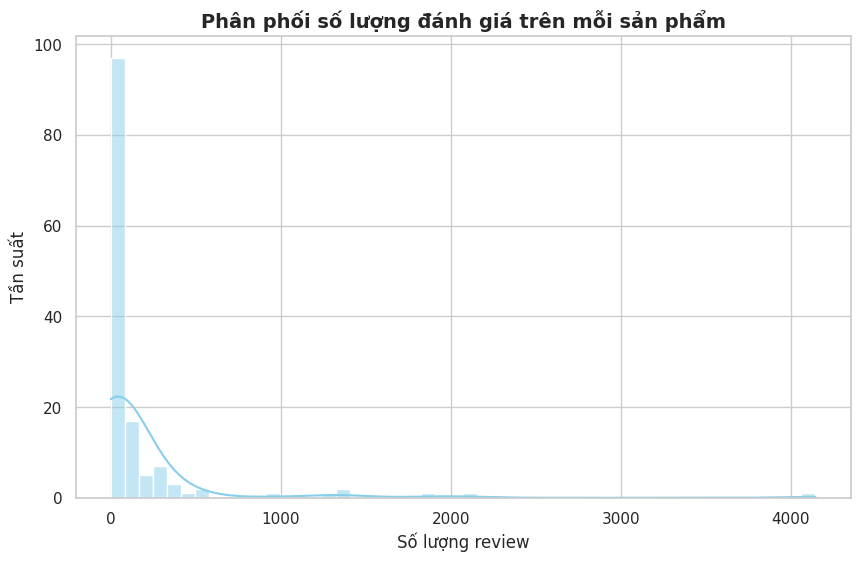

In [ ]:
product_counts = reviews['product_id'].value_counts()

sns.histplot(product_counts, bins=50, kde=True, color='skyblue')

plt.title("Phân phối số lượng đánh giá trên mỗi sản phẩm", fontsize=14, fontweight='bold')
plt.xlabel("Số lượng review", fontsize=12)
plt.ylabel("Tần suất", fontsize=12)

plt.show()

👤 3. PHÂN PHỐI SỐ REVIEW THEO USER

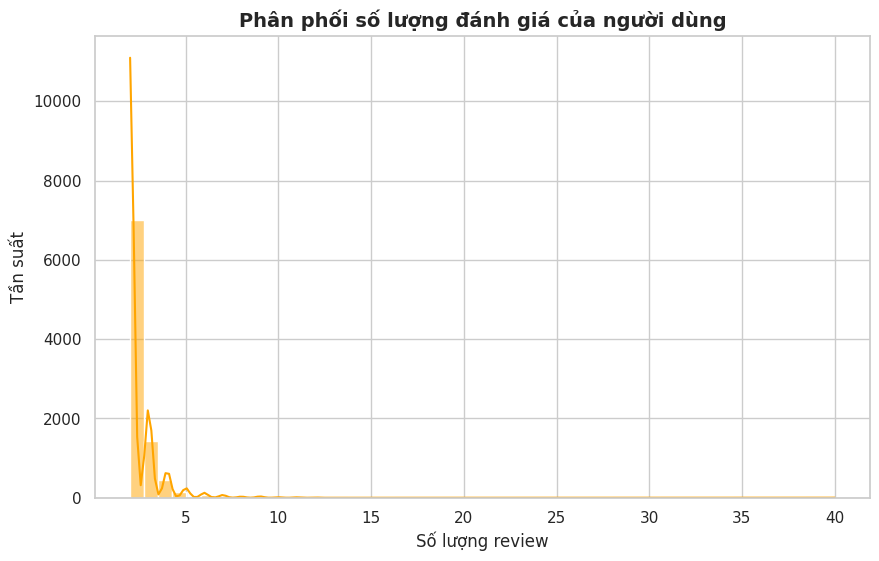

In [ ]:
user_counts = reviews['customer_id'].value_counts()

sns.histplot(user_counts, bins=50, kde=True, color='orange')

plt.title("Phân phối số lượng đánh giá của người dùng", fontsize=14, fontweight='bold')
plt.xlabel("Số lượng review", fontsize=12)
plt.ylabel("Tần suất", fontsize=12)

plt.show()

📈 4. MỐI QUAN HỆ GIỮA SỐ REVIEW VÀ RATING

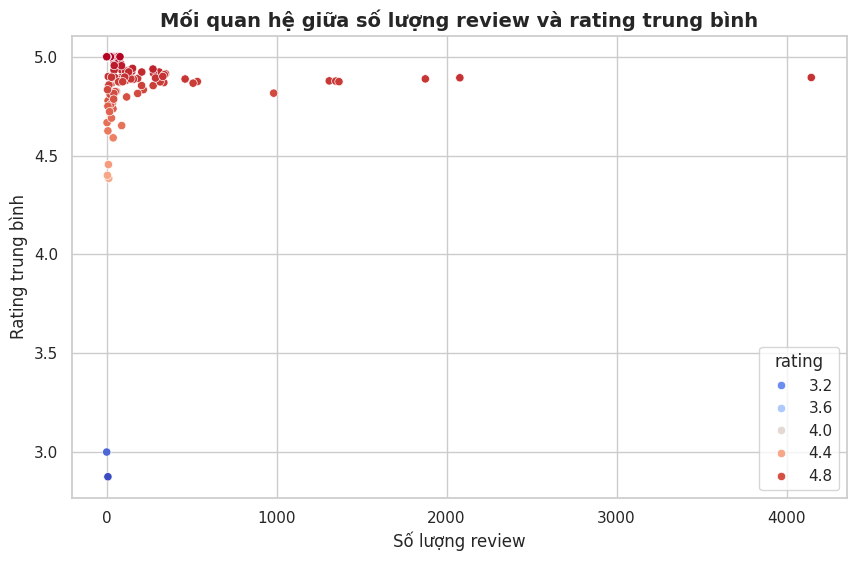

In [ ]:
product_stats = reviews.groupby('product_id').agg({
    'rating': 'mean',
    'review_id': 'count'
}).reset_index()

sns.scatterplot(
    data=product_stats,
    x='review_id',
    y='rating',
    hue='rating',
    palette='coolwarm'
)

plt.title("Mối quan hệ giữa số lượng review và rating trung bình", fontsize=14, fontweight='bold')
plt.xlabel("Số lượng review", fontsize=12)
plt.ylabel("Rating trung bình", fontsize=12)

plt.show()

📊 5. PHÂN PHỐI RATING THEO DANH MỤC

/tmp/ipykernel_13633/3542964710.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


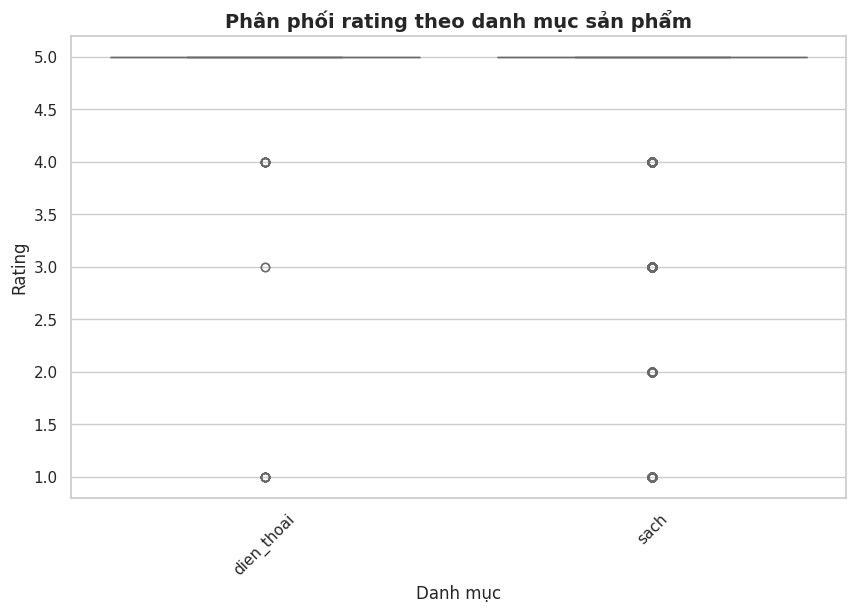

In [ ]:
merged = reviews.merge(products, left_on='product_id', right_on='id')

sns.boxplot(
    data=merged,
    x='category_name_y',
    y='rating',
    palette='Set3'
)

plt.xticks(rotation=45)
plt.title("Phân phối rating theo danh mục sản phẩm", fontsize=14, fontweight='bold')
plt.xlabel("Danh mục", fontsize=12)
plt.ylabel("Rating", fontsize=12)

plt.show()

🔥 6. TOP 10 SẢN PHẨM NHIỀU REVIEW NHẤT

/tmp/ipykernel_13633/1248359351.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


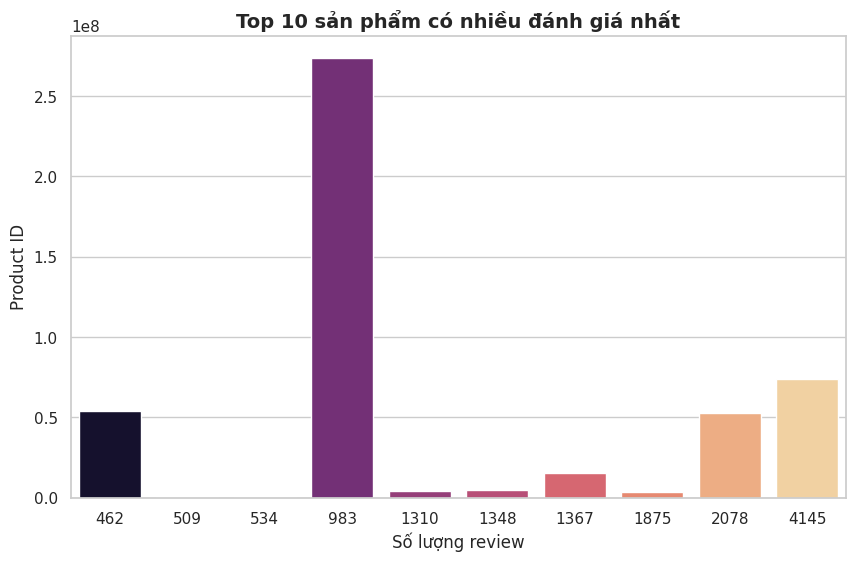

In [ ]:
top_products = reviews['product_id'].value_counts().head(10)

sns.barplot(
    x=top_products.values,
    y=top_products.index,
    palette='magma'
)

plt.title("Top 10 sản phẩm có nhiều đánh giá nhất", fontsize=14, fontweight='bold')
plt.xlabel("Số lượng review", fontsize=12)
plt.ylabel("Product ID", fontsize=12)

plt.show()

🌊 7. DENSITY RATING (ĐẸP)

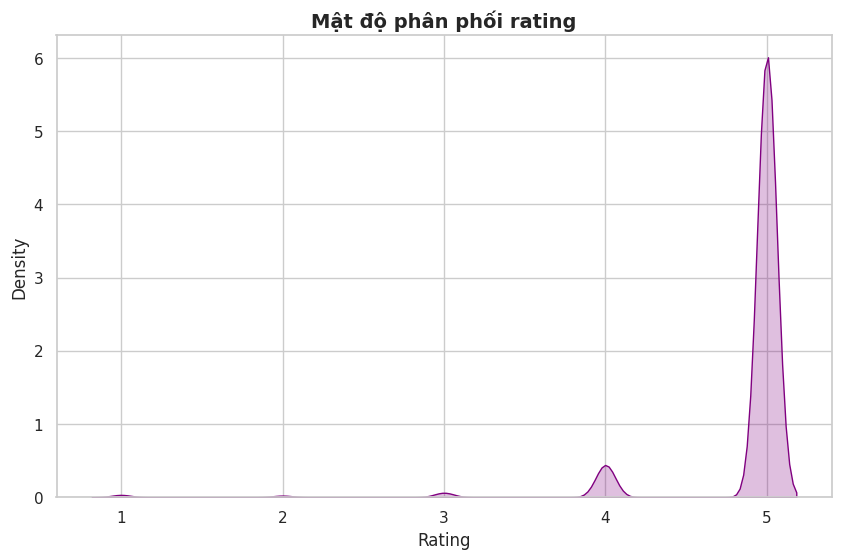

In [ ]:
sns.kdeplot(data=reviews, x='rating', fill=True, color='purple')

plt.title("Mật độ phân phối rating", fontsize=14, fontweight='bold')
plt.xlabel("Rating", fontsize=12)

plt.show()

💰 8. GIÁ VS RATING (XỊN)

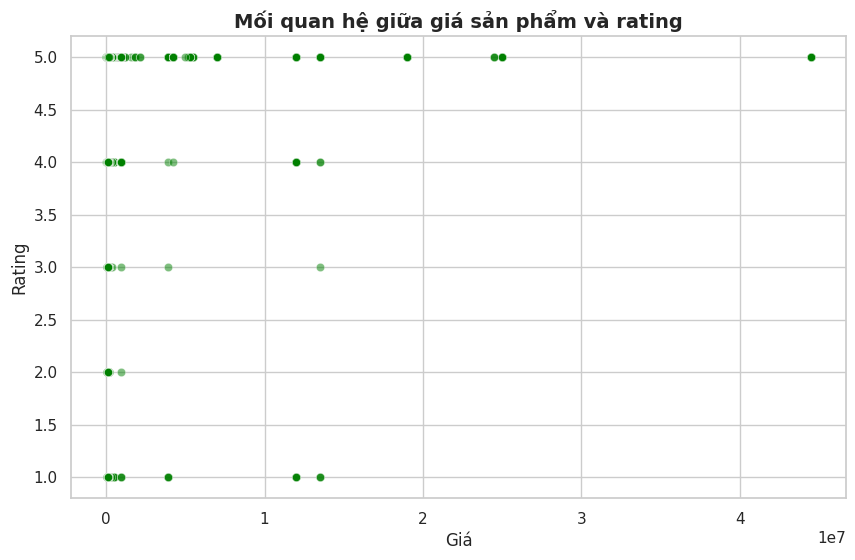

In [ ]:
merged = reviews.merge(products, left_on='product_id', right_on='id')

sns.scatterplot(
    data=merged,
    x='price',
    y='rating',
    alpha=0.5,
    color='green'
)

plt.title("Mối quan hệ giữa giá sản phẩm và rating", fontsize=14, fontweight='bold')
plt.xlabel("Giá", fontsize=12)
plt.ylabel("Rating", fontsize=12)

plt.show()

🧠 9. HEATMAP SPARSITY (ĂN ĐIỂM CAO)

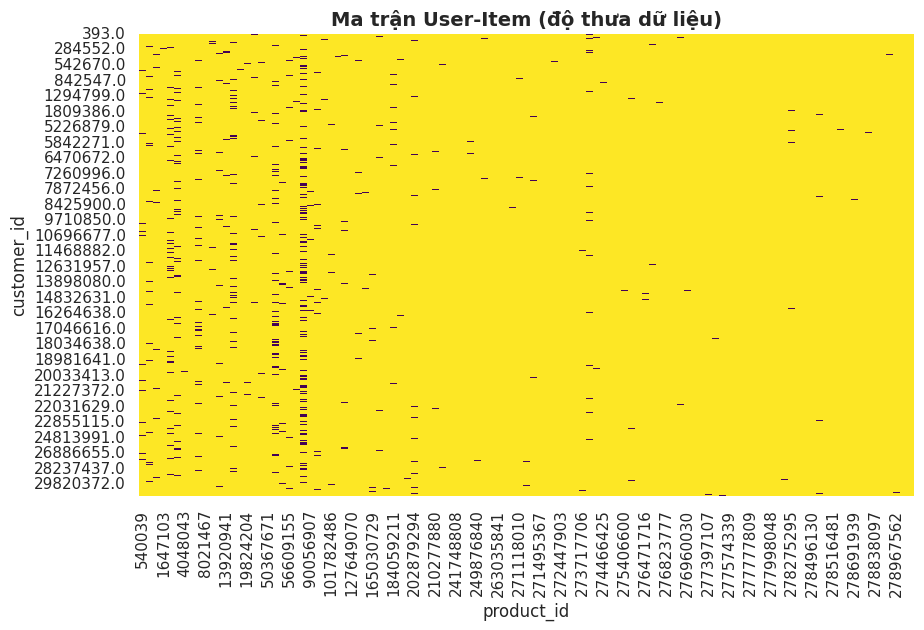

In [ ]:
sample = reviews.sample(3000)

pivot = sample.pivot_table(
    index='customer_id',
    columns='product_id',
    values='rating'
)

sns.heatmap(pivot.isnull(), cbar=False, cmap='viridis')

plt.title("Ma trận User-Item (độ thưa dữ liệu)", fontsize=14, fontweight='bold')

plt.show()

#🚀 BƯỚC TIẾP: BUILD MODEL (SVD)

🔥 BƯỚC 1: CÀI THƯ VIỆN

In [ ]:
!pip install scikit-surprise

📦 BƯỚC 2: IMPORT

In [ ]:
!pip uninstall -y numpy
!pip install numpy==1.26.4
!pip uninstall -y scikit-surprise
!pip install scikit-surprise


Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 45.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires nump

Found existing installation: scikit-surprise 1.1.4
Uninstalling scikit-surprise-1.1.4:
  Successfully uninstalled scikit-surprise-1.1.4
  Using cached scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl


In [ ]:
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split
from surprise import accuracy

📊 BƯỚC 3: CHUẨN BỊ DATA

In [ ]:
import pandas as pd
data = pd.read_csv('/content/Tiki_reviews_clean.csv')
data = data[['customer_id', 'product_id', 'rating']]

In [ ]:
reader = Reader(rating_scale=(1, 5))

dataset = Dataset.load_from_df(data, reader)

✂️ BƯỚC 4: TRAIN TEST SPLIT

In [ ]:
trainset, testset = train_test_split(dataset, test_size=0.2)

🤖 BƯỚC 5: TRAIN MODEL SVD

In [ ]:
model = SVD()

model.fit(trainset)

📈 BƯỚC 6: PREDICT

In [ ]:
predictions = model.test(testset)

📏 BƯỚC 7: ĐÁNH GIÁ MODEL

In [ ]:
print("RMSE:", accuracy.rmse(predictions))
print("MAE:", accuracy.mae(predictions))

RMSE: 0.4588
RMSE: 0.4588133083391941
MAE:  0.2156
MAE: 0.215604174057592


🔥 BƯỚC 8: GỢI Ý SẢN PHẨM (IMPORTANT)

In [ ]:
def recommend_products(user_id, model, data, products, n=5):
    all_products = data['product_id'].unique()

    predictions = []

    for product_id in all_products:
        pred = model.predict(user_id, product_id)
        predictions.append((product_id, pred.est))

    # sort giảm dần theo rating dự đoán
    predictions.sort(key=lambda x: x[1], reverse=True)

    top_n = predictions[:n]

    # merge với product name
    result = []
    for pid, rating in top_n:
        name = products[products['id'] == pid]['name'].values
        if len(name) > 0:
            result.append((pid, name[0], rating))

    return result

In [ ]:
reviews = pd.read_csv('/content/Tiki_reviews_clean.csv')
products = pd.read_csv('/content/Tiki_products_clean.csv')

user_sample = reviews['customer_id'].iloc[0]

recommend_products(user_sample, model, data, products, n=5)

[(276110349, 'Apple iPhone 16', 5),
 (4048043, 'Điện Thoại Bàn Panasonic KX-TS500', 5),
 (271234577, 'Điện Thoại Nokia 105 4G Pro - Hàng Chính Hãng', 5),
 (181928208, 'Điện thoại bàn Panasonic KX-TGC310 hàng chính hãng', 5),
 (278967562, 'Monster - Deluxe Edition –  [Chọn Tập Lẻ', 5)]

In [ ]:
import json

user_sample = reviews['customer_id'].iloc[0]
recommendations = recommend_products(user_sample, model, data, products, n=5)

# Convert numpy.int64 to standard Python int for JSON serialization
serializable_recommendations = []
for pid, name, rating in recommendations:
    serializable_recommendations.append({
        "product_id": int(pid), # Convert product_id from numpy.int64 to standard int
        "product_name": name,
        "predicted_rating": float(rating) # Ensure rating is a standard float
    })

output = {
    "user_id": int(user_sample), # Convert user_sample (float64) to standard int
    "recommendations": serializable_recommendations
}

with open('/content/recommendations.json', 'w', encoding='utf-8') as f:
    json.dump(output, f, ensure_ascii=False, indent=4)

print("Đã lưu file recommendations.json")

Đã lưu file recommendations.json


In [ ]:
from google.colab import files
files.download('/content/recommendations.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>